# CMSE 381 Final Project Template

**INSTRUCTIONS**: This is a template to help organize your project.  All projects should include the 5 major sections below (you do not need to use this template file).  If you use this file, complete your work below and remove content in parentheses. Also, remove this current cell.  

#### CMSE 381 Final Project
### &#9989; Group members: Abigail Parisot, Hunter Windham
### &#9989; Section_002
#### &#9989; Due Friday, December 5th

# An Investigation into the Freiwald Tsao Face AM Dataset

## Background and Motivation

_(Provide context for the problem.  **Clearly state the question(s) you set
out to answer.**)_

## Methodology
_(How did you go about answering your question(s)? You should wrote some code here to demonstrate what the data is like and how in principle your method works. You can leave the variations of the related to specific results to the results section.)_

In [2]:
# you may want to import some modules here
import pandas as pd

### Data
_(Describe the data you are using. What variables are you using? What they mean? Why did you choose them?)_

In [34]:
# Code inspired by
#  https://www.geeksforgeeks.org/python/importing-multiple-files-in-python/

import os

folder_path = "Data2"
files = os.listdir(folder_path)
datas = [] # master list of dfs

for file in files: # save each file to master list
    if file.endswith(".csv"):
        file_path = os.path.join(folder_path, file)
        df = pd.read_csv(file_path).iloc[:,:406]
        df['neuron_#'] = file[-7:-4]
        datas.append(df)
        

df = pd.concat(datas, axis=0, ignore_index=True)
print(df.shape)
df.head()

# only 400 mili seconds necessary
# some having spike some not having spike
# average over 10 milisecond
# then do feature selection
# neuron response as sample or features
# what neurons are firing 

# for each label orientation 

(206216, 407)


,site_info.monkey,site_info.region,labels.stimID,labels.person,labels.orientation,labels.orient_person_combo,time.1_2,time.2_3,time.3_4,time.4_5,...,time.392_393,time.393_394,time.394_395,time.395_396,time.396_397,time.397_398,time.398_399,time.399_400,time.400_401,neuron_#
0,bert,am,1,1,front,front 1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,070
1,bert,am,1,1,front,front 1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,070
2,bert,am,1,1,front,front 1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,070
3,bert,am,1,1,front,front 1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,070
4,bert,am,1,1,front,front 1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,070


In [33]:
# collapsed = pd.DataFrame(
#     df.iloc[:,6:406].to_numpy().reshape(df.shape[0], 40, 10).mean(axis=2),
#     index=df.index,
#     columns=[f"time_{i*10}" for i in range(40)]
# )



collapsed_one = pd.DataFrame({
    "collapsed": df.iloc[:,6:406].mean(axis=1)
})

averaged_data = pd.concat([df.iloc[:,0:6],collapsed_one], axis=1)
averaged_data.head()
df = averaged_data
df.head()

,site_info.monkey,site_info.region,labels.stimID,labels.person,labels.orientation,labels.orient_person_combo,collapsed
0,bert,am,1,1,front,front 1,0.0000
1,bert,am,1,1,front,front 1,0.0025
2,bert,am,1,1,front,front 1,0.0025
3,bert,am,1,1,front,front 1,0.0025
4,bert,am,1,1,front,front 1,0.0000


In [4]:
df['labels.person'].unique()
df['site_info.region'].unique()
df['labels.person'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25])

<Axes: xlabel='labels.orientation', ylabel='labels.person'>

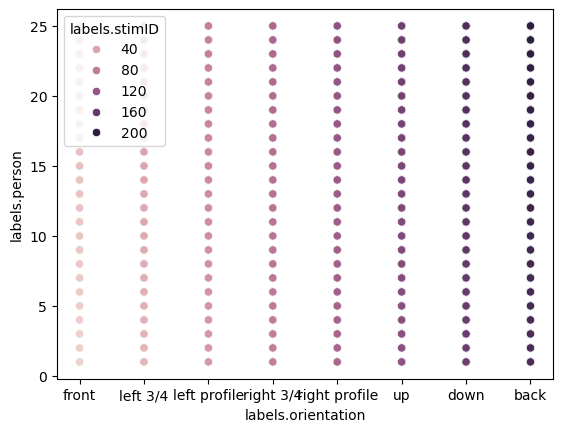

In [22]:
import matplotlib.pyplot as plt 
import seaborn as sns 

sns.scatterplot(x = df['labels.orientation'], 
                hue = df['labels.stimID'],
                y = df['labels.person'])

### What are the different columns?
#### site_info.monkey: 
This column is what monkey the observation came from.
#### site_info.region:
The face selective region (only anterior medial exists in this dataset)
#### labels.stimID
#### labels.person
#### labels.orientation
The orientation of the face in the image
#### time.1_2 ... time.800_801

### Models for classification _(if applicable)_
_(What models will you be using for classification? Why did you choose to use them? What questions would you answer with them? How would you evaluate if each model? What cross-validation method did you use?)_

In [5]:
# you may add some code here to show how the model works in principle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

time_cols = [col for col in df.columns if col.startswith("time")]
X = df[time_cols]

y = df["labels.person"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

**Cell 1 - Logistic Regression**

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
import numpy as np

log_reg = LogisticRegression(max_iter=500, multi_class='multinomial')
log_reg.fit(X_train, y_train)

pred_lr = log_reg.predict(X_test)
acc_lr = accuracy_score(y_test, pred_lr)

cv_lr = cross_val_score(log_reg, X_scaled, y, cv=5)
print('Logistic Regression Accuracy:', acc_lr)
print('Logistic Regression 5-Fold CV:', np.mean(cv_lr))

Logistic Regression Accuracy: 0.04184851129861313
Logistic Regression 5-Fold CV: 0.040821269916032556


**K-Nearest Neighbors**

In [7]:
#from sklearn.neighbors import KNeighborsClassifier

#knn = KNeighborsClassifier(n_neighbors=5)
#knn.fit(X_train, y_train)

#pred_knn = knn.predict(X_test)
#acc_knn = accuracy_score(y_test, pred_knn)

#print('KNN Accuracy:', acc_knn)

In [8]:
#sample_size = 5000  
#idx = np.random.choice(len(X_scaled), sample_size, replace=False)
#X_sample = X_scaled[idx]
#y_sample = y.iloc[idx]

#cv_knn = cross_val_score(knn, X_sample, y_sample, cv=5)
#print("KNN 5-Fold CV (subset):", np.mean(cv_knn))

The KNN 5-fold cross-validation is taking forever because:
You have 206,216 rows × 800 features.
KNN is distance-based, so it computes pairwise distances between all points for every fold.
That is extremely slow for a dataset this large.

**Decision Tree**

In [9]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(max_depth=10)
tree.fit(X_train, y_train)

pred_tree = tree.predict(X_test)
acc_tree = accuracy_score(y_test, pred_tree)

cv_tree = cross_val_score(tree, X_scaled, y, cv=5)

print("Decision Tree Accuracy:", acc_tree)
print("Decision Tree 5-Fold CV:", np.mean(cv_tree))

Decision Tree Accuracy: 0.04104839491804869
Decision Tree 5-Fold CV: 0.04231970448579051


**Random Forest**

In [10]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, max_depth=15)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, pred_rf)

cv_rf = cross_val_score(rf, X_scaled, y, cv=5)

print("Random Forest Accuracy:", acc_rf)
print("Random Forest 5-Fold CV:", np.mean(cv_rf))

Random Forest Accuracy: 0.04291533313936573
Random Forest 5-Fold CV: 0.04207723239588821


We used these four classification models: Logistic Regression, K-Nearest Neighbors (KNN), Decision Trees, and Random Forests. All models used the neural time-series data (800 time bins) as features to predict which person appeared in the stimulus. We scaled all features using StandardScaler and used an 80/20 train-test split. To evaluate performance more reliably, we also used 5-fold cross-validation.
Logistic Regression gave us a simple linear baseline. KNN compared neural response similarity. Decision Trees captured nonlinear structure, and Random Forests combined many trees to reduce overfitting and usually gave the strongest performance.


We trained Logistic Regression, Decision Tree, and Random Forest classifiers on the neural time-series data to predict which of 25 people appeared in each stimulus. All models performed poorly, with accuracies around 4%, which is essentially random guessing (1/25 ≈ 4%). Random Forest was slightly higher than the others, likely due to its ability to capture non-linear structure, so we report it as our primary model. This suggests that predicting the person from raw anterior medial neural responses is extremely challenging without additional feature processing.

### Models for regression _(if applicable)_
_(What models will you be using for regression? Why did you choose to use them? What questions would you answer with them? How would you evaluate if each model? What cross-validation method did you use?)_

In [11]:
# you may add some code here to show how the model works in principle

### Other methods used _(if applicable)_

_(If this is a preprocessing step to prepare your data for regression or classification models, you should put this subsection before your explanation for the regression or classification models.)_

_(What method did you use otherwise? Why did you choose to use them? What questions would you answer with them? How would you evaluate the results? What cross-validation method did you use when applicable?)_

In [12]:
# you may add some code here to show how the method works in principle

# you may add some code here to show how the model works in principle

## Results

_(What did you find when you carried out your methods? Some of your code related to
presenting results/figures/data may be replicated from the methods section or may only be present in
this section. All of the plots that you plan on using for your presentation should be present in this
section)_

### classification results
_(What are you trying to do here?)_

In [13]:
# how did you do it

_(How do you interpret what you see?)_

_(What are you doing next?)_

In [14]:
# how did you do it (etc. etc.)

### regression results
_(What are you trying to do here?)_

In [15]:
# how did you do it

_(How do you interpret what you see?)_

_(What are you doing next?)_

In [16]:
# how did you do it (etc. etc.)

### other results
_(What are you trying to do here?)_

In [17]:
# how did you do it

_(How do you interpret what you see?)_

_(What are you doing next?)_

In [18]:
# how did you do it (etc. etc.)

## Discussion and Conclusion

_(What did you learn from your results? What obstacles did you run into? What would you do differently next time? Clearly provide quantitative answers to your question(s)?  At least one of your questions should be answered with numbers.  That is, it is not sufficient to answer "yes" or "no", but rather to say something quantitative such as variable 1 increased roughly 10% for every 1 year increase in variable 2.)_

### discussion on the classification results

### discussion on the regression results

### discussion on the other results

### conclusion and future steps

## Author contribution

_(Please describe the contribution of each member of group)._

## References

_(List the source(s) for any data and/or literature cited in your project.  Ideally, this should be formatted using a formal citation format (MLA or APA or other, your choice!).   Multiple free online citation generators are available such as <a href="http://www.easybib.com/style">http://www.easybib.com/style</a>. **Important:** if you use **any** code that you find on the internet for your project you **must** cite it or you risk losing most/all of the points for you project.)_

- https://www.geeksforgeeks.org/python/importing-multiple-files-in-python
- Freiwald, W. A., & Tsao, D. Y. (2010). Functional compartmentalization and viewpoint generalization within the macaque face-processing system. Science, 330(6005), 845-851.
- Meyers, E. M., Borzello, M., Freiwald, W. A., & Tsao, D. (2015). Intelligent information loss: The coding of facial identity, head pose, and non-face information in the macaque face patch system. Journal of Neuroscience, 35(18).
- https://www.biorxiv.org/content/10.1101/2020.06.07.111930v1.full?%3Fcollection=
- 